# 📈 04 — Training & Validation Loss Curves

This notebook parses the Ultralytics `results.csv` from the YOLO26m training run
and generates a **single combined figure** with all loss and metric curves.

### Output
- **Combined plot**: Train/Val box, cls, DFL losses + mAP₅₀ / mAP₅₀₋₉₅ trends
- Saved to: `outputs/training_curves.png`

In [1]:
# ============================================================
#  Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# Apply a clean, modern style
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 150,
})

print("Imports complete ✓")

Imports complete ✓


In [2]:
# ============================================================
#  Configuration
# ============================================================

PROJECT_ROOT = Path("..")

RESULTS_CSV = PROJECT_ROOT / "runs" / "detect" / "retail_shelf_yolo26m" / "results.csv"
OUTPUT_DIR  = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PATH = OUTPUT_DIR / "training_curves.png"

print(f"Results CSV: {RESULTS_CSV.resolve()}")
print(f"Output Path: {SAVE_PATH.resolve()}")
print(f"CSV exists:  {RESULTS_CSV.exists()}")

Results CSV: /home/rakib/Desktop/OFFICE/Projects/ALL Products/runs/detect/retail_shelf_yolo26m/results.csv
Output Path: /home/rakib/Desktop/OFFICE/Projects/ALL Products/outputs/training_curves.png
CSV exists:  True


In [3]:
# ============================================================
#  Load & Clean Results
# ============================================================

df = pd.read_csv(RESULTS_CSV)

# Clean column names (Ultralytics adds leading/trailing spaces)
df.columns = df.columns.str.strip()

# Create epoch column (1-indexed)
df["epoch"] = df.index + 1

print(f"Loaded {len(df)} epochs of training data.")
print(f"\nAvailable columns:")
for col in df.columns:
    print(f"  • {col}")

print(f"\nFinal epoch metrics:")
print(f"  mAP50:     {df['metrics/mAP50(B)'].iloc[-1]:.4f}")
print(f"  mAP50-95:  {df['metrics/mAP50-95(B)'].iloc[-1]:.4f}")

Loaded 73 epochs of training data.

Available columns:
  • epoch
  • time
  • train/box_loss
  • train/cls_loss
  • train/dfl_loss
  • metrics/precision(B)
  • metrics/recall(B)
  • metrics/mAP50(B)
  • metrics/mAP50-95(B)
  • val/box_loss
  • val/cls_loss
  • val/dfl_loss
  • lr/pg0
  • lr/pg1
  • lr/pg2
  • lr/pg3
  • lr/pg4
  • lr/pg5
  • lr/pg6
  • lr/pg7

Final epoch metrics:
  mAP50:     0.7038
  mAP50-95:  0.4580


## 📊 Combined Training Curves

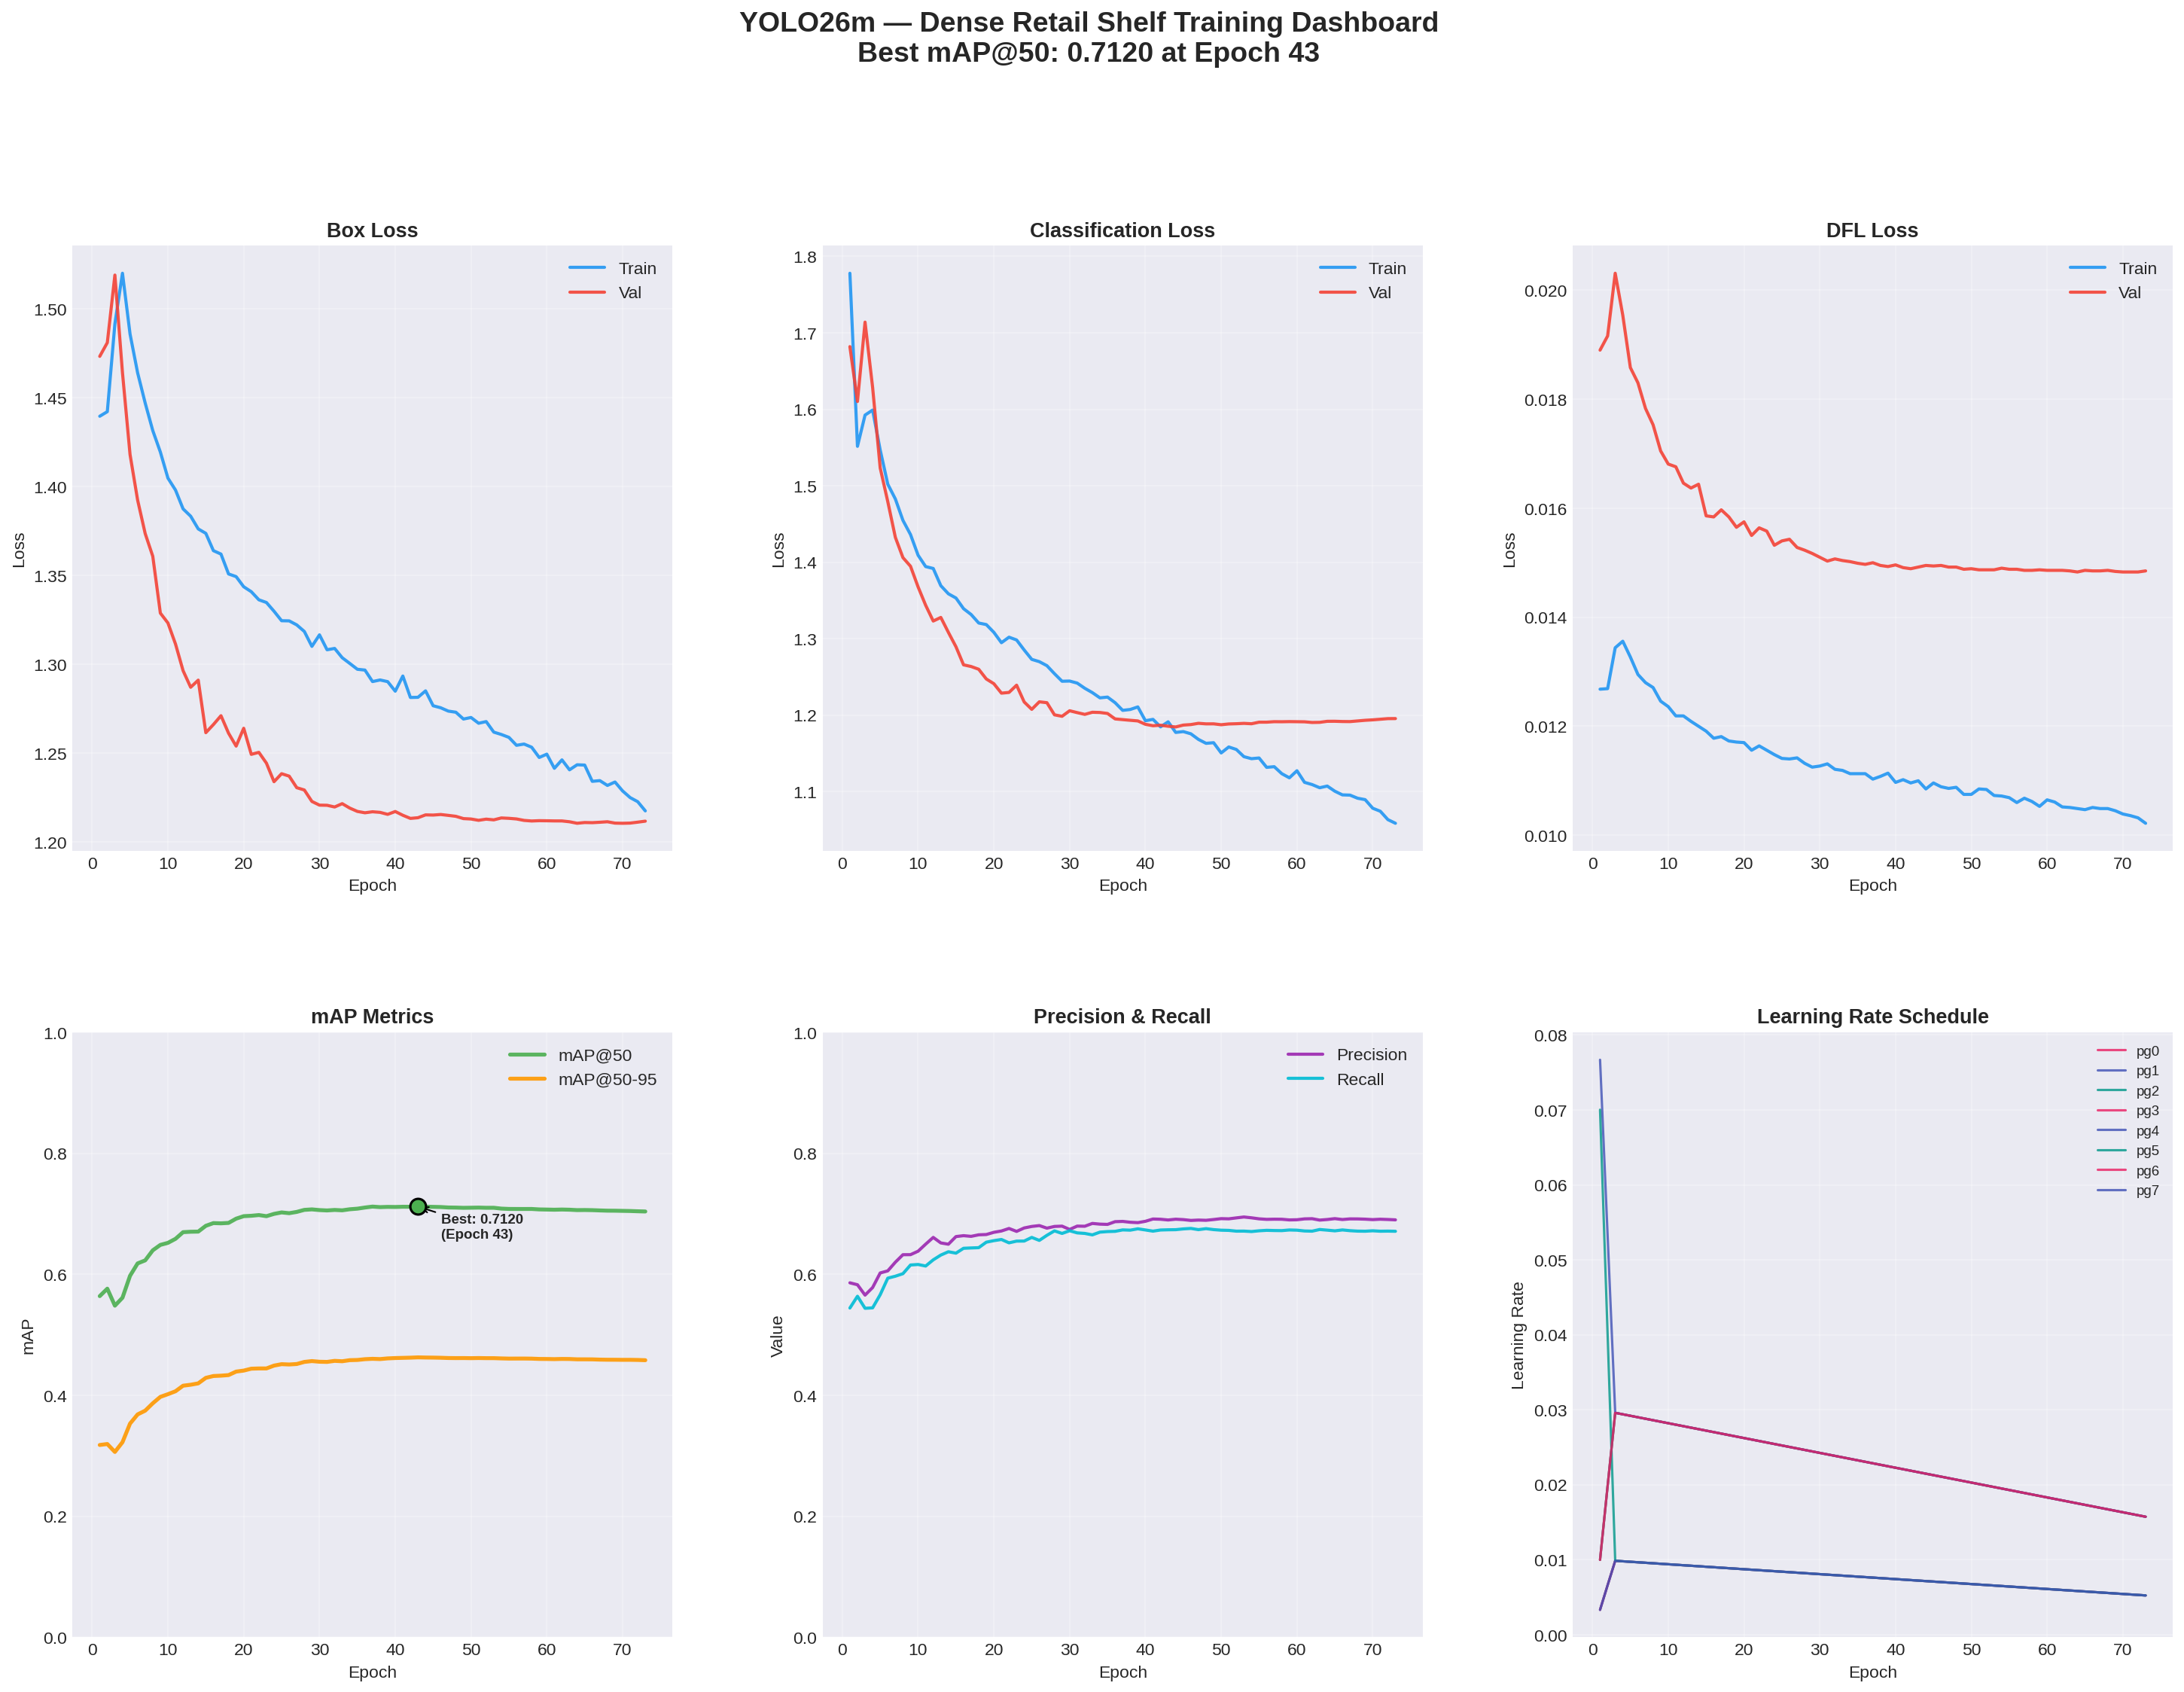


✅ Training curves saved to: /home/rakib/Desktop/OFFICE/Projects/ALL Products/outputs/training_curves.png


In [4]:
# ============================================================
#  Plot all curves in a single figure
# ============================================================

# Color palette — vibrant and distinguishable
COLORS = {
    "train": "#2196F3",     # Blue
    "val":   "#F44336",     # Red
    "map50":  "#4CAF50",    # Green
    "map95":  "#FF9800",    # Orange
    "prec":   "#9C27B0",    # Purple
    "recall": "#00BCD4",    # Cyan
    "lr":     "#795548",    # Brown
}

fig = plt.figure(figsize=(24, 16))
gs = gridspec.GridSpec(2, 3, hspace=0.30, wspace=0.25)

epochs = df["epoch"]

# ----------------------------------------------------------
#  1. Box Loss (Train vs Val)
# ----------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, df["train/box_loss"], color=COLORS["train"],
         linewidth=2, alpha=0.9, label="Train")
ax1.plot(epochs, df["val/box_loss"], color=COLORS["val"],
         linewidth=2, alpha=0.9, label="Val")
ax1.set_title("Box Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(framealpha=0.9)
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------
#  2. Classification Loss (Train vs Val)
# ----------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, df["train/cls_loss"], color=COLORS["train"],
         linewidth=2, alpha=0.9, label="Train")
ax2.plot(epochs, df["val/cls_loss"], color=COLORS["val"],
         linewidth=2, alpha=0.9, label="Val")
ax2.set_title("Classification Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend(framealpha=0.9)
ax2.grid(True, alpha=0.3)

# ----------------------------------------------------------
#  3. DFL Loss (Train vs Val)
# ----------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs, df["train/dfl_loss"], color=COLORS["train"],
         linewidth=2, alpha=0.9, label="Train")
ax3.plot(epochs, df["val/dfl_loss"], color=COLORS["val"],
         linewidth=2, alpha=0.9, label="Val")
ax3.set_title("DFL Loss")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Loss")
ax3.legend(framealpha=0.9)
ax3.grid(True, alpha=0.3)

# ----------------------------------------------------------
#  4. mAP Curves
# ----------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(epochs, df["metrics/mAP50(B)"], color=COLORS["map50"],
         linewidth=2.5, alpha=0.9, label="mAP@50")
ax4.plot(epochs, df["metrics/mAP50-95(B)"], color=COLORS["map95"],
         linewidth=2.5, alpha=0.9, label="mAP@50-95")

# Mark best mAP50
best_idx = df["metrics/mAP50(B)"].idxmax()
best_val = df["metrics/mAP50(B)"].iloc[best_idx]
ax4.scatter(best_idx + 1, best_val, color=COLORS["map50"],
           s=100, zorder=5, edgecolors="black", linewidth=1.5)
ax4.annotate(f"Best: {best_val:.4f}\n(Epoch {best_idx + 1})",
            xy=(best_idx + 1, best_val),
            xytext=(15, -20), textcoords="offset points",
            fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="black"))

ax4.set_title("mAP Metrics")
ax4.set_xlabel("Epoch")
ax4.set_ylabel("mAP")
ax4.set_ylim(0, 1.0)
ax4.legend(framealpha=0.9)
ax4.grid(True, alpha=0.3)

# ----------------------------------------------------------
#  5. Precision & Recall
# ----------------------------------------------------------
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(epochs, df["metrics/precision(B)"], color=COLORS["prec"],
         linewidth=2, alpha=0.9, label="Precision")
ax5.plot(epochs, df["metrics/recall(B)"], color=COLORS["recall"],
         linewidth=2, alpha=0.9, label="Recall")
ax5.set_title("Precision & Recall")
ax5.set_xlabel("Epoch")
ax5.set_ylabel("Value")
ax5.set_ylim(0, 1.0)
ax5.legend(framealpha=0.9)
ax5.grid(True, alpha=0.3)

# ----------------------------------------------------------
#  6. Learning Rate Schedule
# ----------------------------------------------------------
ax6 = fig.add_subplot(gs[1, 2])
lr_cols = [c for c in df.columns if c.startswith("lr/")]
lr_colors = ["#E91E63", "#3F51B5", "#009688"]
for i, col in enumerate(lr_cols):
    color = lr_colors[i % len(lr_colors)]
    label = col.replace("lr/", "")
    ax6.plot(epochs, df[col], color=color,
             linewidth=1.5, alpha=0.8, label=label)
ax6.set_title("Learning Rate Schedule")
ax6.set_xlabel("Epoch")
ax6.set_ylabel("Learning Rate")
ax6.legend(framealpha=0.9, fontsize=9)
ax6.grid(True, alpha=0.3)

# ----------------------------------------------------------
#  Final touches
# ----------------------------------------------------------
fig.suptitle(
    "YOLO26m — Dense Retail Shelf Training Dashboard\n"
    f"Best mAP@50: {best_val:.4f} at Epoch {best_idx + 1}",
    fontsize=18, fontweight="bold", y=1.01
)

# Save high-resolution figure
fig.savefig(SAVE_PATH, dpi=200, bbox_inches="tight",
            facecolor="white", edgecolor="none")

plt.show()

print(f"\n✅ Training curves saved to: {SAVE_PATH.resolve()}")

## 📋 Epoch-by-Epoch Summary Table

In [5]:
# ============================================================
#  Display key metrics as a table
# ============================================================

summary_cols = [
    "epoch",
    "train/box_loss", "train/cls_loss",
    "val/box_loss", "val/cls_loss",
    "metrics/precision(B)", "metrics/recall(B)",
    "metrics/mAP50(B)", "metrics/mAP50-95(B)",
]

# Show every 10th epoch + first and last
display_epochs = sorted(set([0, len(df)-1] + list(range(9, len(df), 10))))
summary_df = df[summary_cols].iloc[display_epochs].copy()

# Rename columns for readability
summary_df.columns = [
    "Epoch",
    "Train Box", "Train Cls",
    "Val Box", "Val Cls",
    "Precision", "Recall",
    "mAP50", "mAP50-95",
]

# Format numbers
for col in summary_df.columns[1:]:
    summary_df[col] = summary_df[col].apply(lambda x: f"{x:.4f}")

print("\n📊 Training Summary (sampled every 10 epochs):")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)
print(f"\n✅ Best mAP@50: {best_val:.4f} at Epoch {best_idx + 1}")


📊 Training Summary (sampled every 10 epochs):
 Epoch Train Box Train Cls Val Box Val Cls Precision Recall  mAP50 mAP50-95
     1    1.4396    1.7779  1.4732  1.6820    0.5859 0.5443 0.5639   0.3179
    10    1.4047    1.4091  1.3232  1.3677    0.6382 0.6162 0.6520   0.4018
    20    1.3436    1.3082  1.2639  1.2410    0.6694 0.6556 0.6961   0.4409
    30    1.3165    1.2445  1.2207  1.2057    0.6742 0.6720 0.7062   0.4555
    40    1.2848    1.1926  1.2171  1.1879    0.6876 0.6733 0.7113   0.4616
    50    1.2700    1.1505  1.2129  1.1874    0.6920 0.6729 0.7101   0.4614
    60    1.2494    1.1272  1.2119  1.1913    0.6902 0.6729 0.7070   0.4600
    70    1.2287    1.0782  1.2105  1.1938    0.6904 0.6719 0.7048   0.4586
    73    1.2174    1.0585  1.2117  1.1954    0.6900 0.6711 0.7038   0.4580

✅ Best mAP@50: 0.7120 at Epoch 43
